In [16]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from src.attention import TransformedLayer
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import jax.numpy as jnp
import jax
key = jax.random.key(0)

In [3]:

X = jax.random.uniform(key=key,shape=(15,20))

In [4]:
transformed_layer = TransformedLayer(X)

In [5]:
attention_scores = transformed_layer.get_attentions_scores()

In [6]:
attention_weights = transformed_layer.get_attention_weights()

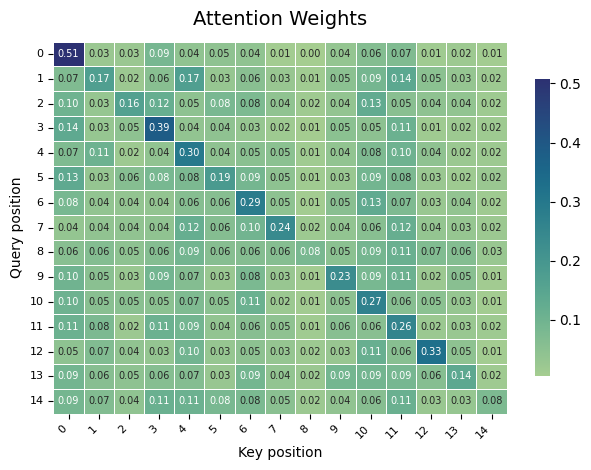

In [ ]:
ax = sns.heatmap(
    attention_weights,
    annot=True,
    cmap="crest",
    fmt=".2f",              
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 7},  
    cbar_kws={"shrink": 0.8}
)

ax.set_title("Attention Weights", fontsize=14, pad=12)
ax.set_xlabel("Key position")
ax.set_ylabel("Query position")

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

In [15]:
a_00 = jnp.exp(X[0] @ X[0]) / (
    jnp.exp(X[0] @ X[0]) +
    jnp.exp(X[0] @ X[1]) +
    jnp.exp(X[0] @ X[2])
)

In [ ]:
a_00

Array(0.533188, dtype=float32)

In [10]:
attention_weights

Array([[0.533188  , 0.21477345, 0.2520386 ],
       [0.4367903 , 0.26892945, 0.29428017],
       [0.40155977, 0.2305429 , 0.36789724]], dtype=float32)

In [13]:
scores = X @ X.T
weights = jax.nn.softmax(scores, axis=-1)

a_00 = weights[0, 0]

In [14]:
a_00

Array(0.533188, dtype=float32)